In [3]:
import pandas as pd
import numpy as np
results = pd.read_csv('results.csv', sep='\t')
results.sort_values(by=['User', 'Query', 'System'], inplace=True)
# # Ignoring wrong submissions
results["Score No Penalty"] = results["Time to correct"].apply(lambda x: 100 - 50 * x / 300 if x else 0)
results["Score No Penalty"].fillna(0, inplace=True)
# results.loc[results["Time to correct"].isna(), "Time to correct"] = 300
results["Hints"] = results["Time to correct"].transform(lambda x: min(x//30, 5))
results['System'] = results['System'].replace({'A': 'MyEachtra', 'B': 'MyScéal'})
results.sort_values(by=['User', 'System', 'Query'], inplace=True)
results

,User,Query,Wrong submissions,Time to correct,System,Score,Score No Penalty,Hints
24,1,1,0,9.267,MyEachtra,98.46,98.455500,0.0
25,1,2,2,47.866,MyEachtra,72.02,92.022333,1.0
26,1,3,2,49.413,MyEachtra,71.76,91.764500,1.0
27,1,4,1,54.921,MyEachtra,80.85,90.846500,1.0
28,1,5,8,NaN,MyScéal,0.00,0.000000,NaN
...,...,...,...,...,...,...,...,...
36,8,5,0,15.830,MyEachtra,97.36,97.361667,0.0
32,8,1,0,17.871,MyScéal,97.02,97.021500,0.0
37,8,6,6,113.433,MyScéal,21.09,81.094500,3.0
38,8,7,0,11.736,MyScéal,98.04,98.044000,0.0


In [4]:
# if hints is nan, right submission = 0, else 1
results["Right submissions"] = [0 if np.isnan(x) else 1 for x in results["Hints"]]

# Significant Test

In [11]:
# conduct significance test to compare the two systems
import scipy.stats as stats

# H0: The two systems have the same performance
# H1: The two systems have different performance

# We will use the Wilcoxon signed-rank test to compare the two systems
# because the data is not normally distributed
# and the two systems are dependent (i.e., the same users are using both systems)

# We will use the score as the dependent variable
# and the system as the independent variable
# and the user as the dependent variable

# Code here
field="Time to correct"
system1_scores = results[results['System'] == 'MyEachtra'][field]
system2_scores = results[results['System'] == 'MyScéal'][field]

# Calculate means
mean1 = np.mean(system1_scores)
mean2 = np.mean(system2_scores)

# Calculate standard deviations
std1 = np.std(system1_scores)
std2 = np.std(system2_scores)

# Calculate sample sizes
n1 = len(system1_scores)
n2 = len(system2_scores)

# Calculate the Z statistic
z = (mean1 - mean2) / np.sqrt(std1**2 / n1 + std2**2 / n2)

# Calculate the two-tailed p-value
p = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Z statistic is {z}")
print(f"P-value is {p}")  

Z statistic is 1.1406127123258907
P-value is 0.2540311247701865


Z statistic is 1.2499849293124738
P-value is 0.21130505268015165
_Results_: Fail to reject the null hypothesis because the p-value is greater than the significance level of 0.05.
_What this means_: There is not enough evidence to conclude that the mean of the two groups is different.
However, 

# Others

In [39]:
results.groupby('System').mean()

,User,Query,Wrong submissions,Time to correct,Score,Score No Penalty,Hints,Right submissions
System,,,,,,,,
MyEachtra,4.5,4.5,1.34375,61.887733,76.580938,84.080042,1.433333,0.9375
MyScéal,4.5,4.5,1.03125,49.308615,68.635000,74.572792,1.076923,0.8125


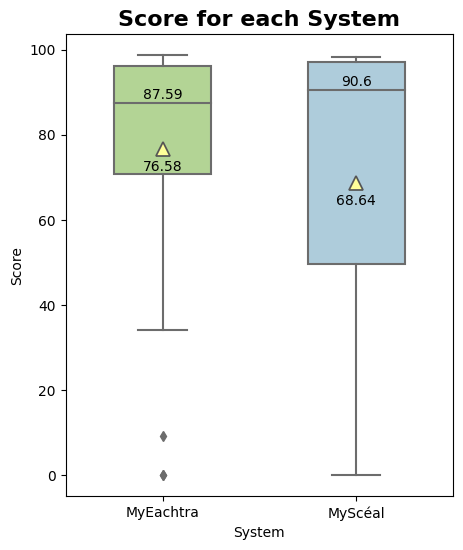

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
palette = ["#b2df8a", "#a6cee3", "#fdbf6f", "#ffff99"]
fig = plt.figure(figsize=(5, 6))
key = "Score"
# Plot 2 box plots for Score for each System with annotations for median and mean values, horizontally

box_plot = sns.boxplot(y=key, x='System', data=results, 
            width=0.5, palette=palette,
            showmeans=True, 
            meanprops={"markerfacecolor": palette[3], 
                       "markeredgecolor":"#555", 
                       "markersize":"10",
                       "markeredgewidth": 1.25},
            bootstrap=1000)
# # Annotations for median and mean values
medians = results.groupby(['System'])[key].median()
vertical_offset = results[key].median() * 0.01 # offset from median for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, medians[xtick] + vertical_offset,
                  round(medians[xtick], 2), 
                  horizontalalignment='center')
# # Annotations for median and mean values
means = results.groupby(['System'])[key].mean()
vertical_offset = - results[key].mean() * 0.07 # offset from mean for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, means[xtick] + vertical_offset,
                  round(means[xtick], 2), 
                  horizontalalignment='center')
plt.title("Score for each System", fontsize=16, fontweight='bold')
plt.savefig("Score.png", dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Right submissions for each System')

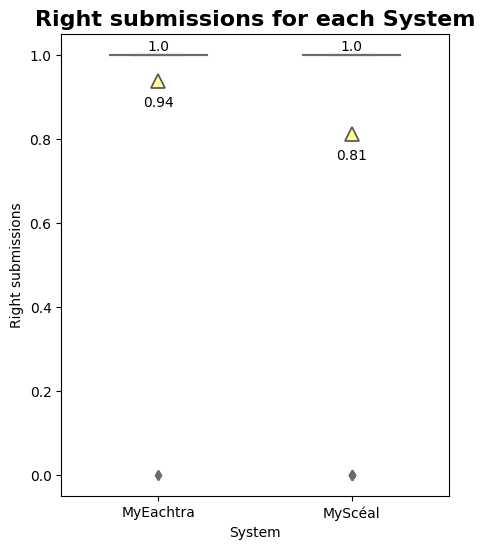

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
palette = ["#b2df8a", "#a6cee3", "#fdbf6f", "#ffff99"]
fig = plt.figure(figsize=(5, 6))
key = "Right submissions"
# Plot 2 box plots for Score for each System with annotations for median and mean values, horizontally

box_plot = sns.boxplot(y=key, x='System', data=results, 
            width=0.5, palette=palette,
            showmeans=True, 
            meanprops={"markerfacecolor": palette[3], 
                       "markeredgecolor":"#555", 
                       "markersize":"10",
                       "markeredgewidth": 1.25},
            bootstrap=1000)
# # Annotations for median and mean values
medians = results.groupby(['System'])[key].median()
vertical_offset = results[key].median() * 0.01 # offset from median for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, medians[xtick] + vertical_offset,
                  round(medians[xtick], 2), 
                  horizontalalignment='center')
# # Annotations for median and mean values
means = results.groupby(['System'])[key].mean()
vertical_offset = - results[key].mean() * 0.07 # offset from mean for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, means[xtick] + vertical_offset,
                  round(means[xtick], 2), 
                  horizontalalignment='center')
plt.title("Right submissions for each System", fontsize=16, fontweight='bold')
# plt.savefig("Score.png", dpi=300, bbox_inches='tight')

In [15]:
# Add an "ALL" Query to the results
all_results = results.groupby(["User", "System"]).mean().reset_index()
all_results["Query"] = "MEAN per User"
results_with_means = pd.concat([results, all_results], ignore_index=True)

/tmp/ipykernel_892290/4019519550.py:9: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  grped_bplot = sns.stripplot(x='Query',


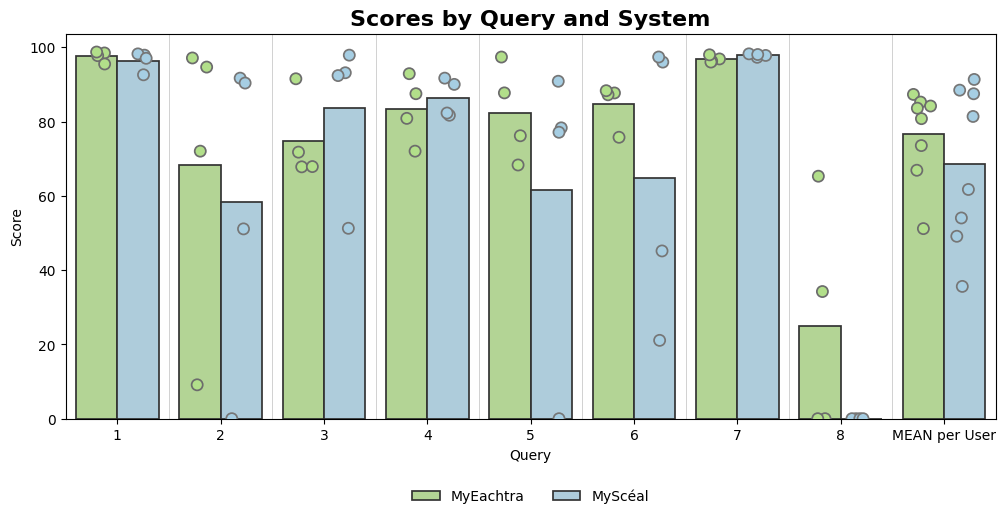

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
key = "Score"

ax = sns.barplot(x='Query', y=key, data=results_with_means, hue='System', width=0.8,
            palette=palette, errorbar=None, alpha=1.0, linewidth=1.25, edgecolor='#333')
# make grouped stripplot
grped_bplot = sns.stripplot(x='Query', 
                            y=key, 
                            hue='System',
                            jitter=0.2,
                            dodge=True, 
                            marker='o', 
                            palette=palette,
                            alpha=1.0,
                            size=8,
                            data=results_with_means,
                            linewidth=1.25, 
                            edgecolors='black', 
                            legend=False)
for i in range(9):
    plt.axvline(x = i + 0.5, color = 'black', linewidth = 0.5, alpha = 0.25)

# move legend outside of plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.title('Scores by Query and System', fontsize=16, fontweight='bold')
plt.savefig("Per_query.png", dpi=300, bbox_inches='tight')
print()

When you plot all the data points for all tasks and all participants, you may be seeing a lot of variability in the scores, which can result in a lower median for System A but a higher mean. This means that some participants may have performed very well with System A, while others may have performed very poorly. This could be reflected in a lower median score, which indicates the middle value of the scores. However, the mean score may be higher for System A because the overall performance of the group was higher due to the strong performance of some participants.

When you compute the mean score for each system per user and plot the mean scores, you may be seeing a different picture. This approach averages the scores across all tasks for each participant, which can result in a more stable measure of performance for each system. In this case, it appears that System A has a better mean and median score than System B. This means that, on average, participants performed better with System A across all tasks.

In [17]:
# Add an "ALL" User to the results
all_results = results.groupby(["Query", "System"]).mean().reset_index()
all_results["User"] = "MEAN per Query"
results_with_means_users = pd.concat([results, all_results], ignore_index=True)

In [35]:
results_with_means_users[-16:].groupby('System')['Score'].mean()

System
MyEachtra    76.580938
MyScéal      68.635000
Name: Score, dtype: float64

/tmp/ipykernel_892290/203359580.py:16: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  grped_bplot = sns.stripplot(x='User',


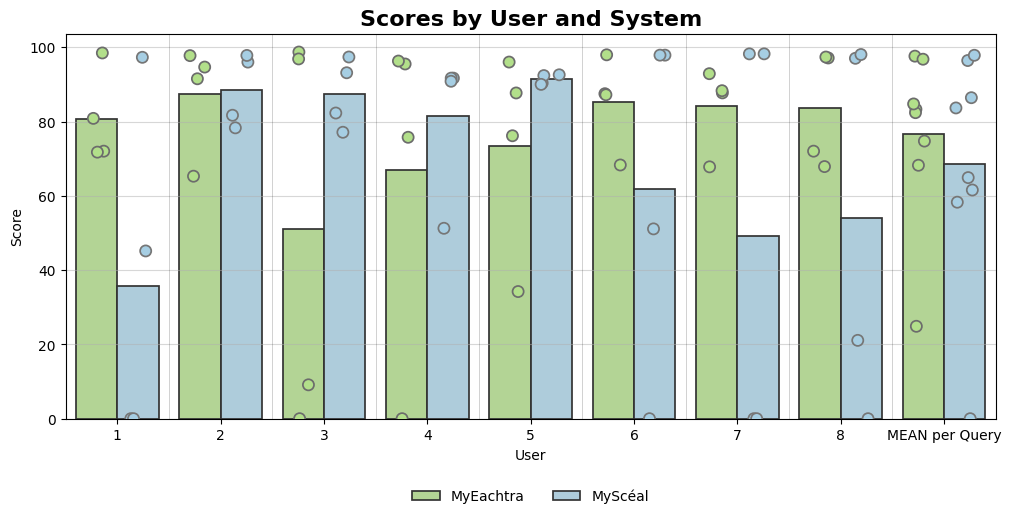

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
key = "Score"

# draw gridlines
plt.grid(axis='y', alpha=0.5)

ax = sns.barplot(x='User', y=key, data=results_with_means_users, hue='System', width=0.8,
            palette=palette, errorbar=None, alpha=1.0, linewidth=1.25, edgecolor='#333')

# move legend outside of plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

# make grouped stripplot
grped_bplot = sns.stripplot(x='User', 
                            y=key, 
                            hue='System',
                            jitter=0.2,
                            dodge=True, 
                            marker='o', 
                            palette=palette,
                            alpha=1.0,
                            size=8,
                            data=results_with_means_users,
                            linewidth=1.25, 
                            edgecolors='black', 
                            legend=False)
for i in range(9):
    plt.axvline(x = i + 0.5, color = 'black', linewidth = 0.5, alpha = 0.25)
plt.title('Scores by User and System', fontsize=16, fontweight='bold')
plt.savefig("Per_user.png", dpi=300, bbox_inches='tight')
print()